<a href="https://colab.research.google.com/github/Mithu06-dev/AIML-Learning-/blob/main/Neive_bayes_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  

Dataset Shape:
(150, 5)

Naive Bayes Accuracy
Accuracy: 0.9666666666666667
Accuracy Percentage: 96.66666666666667 %

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97   

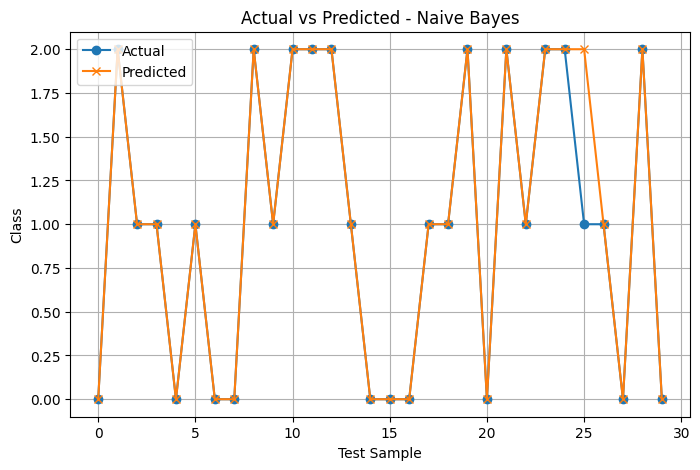

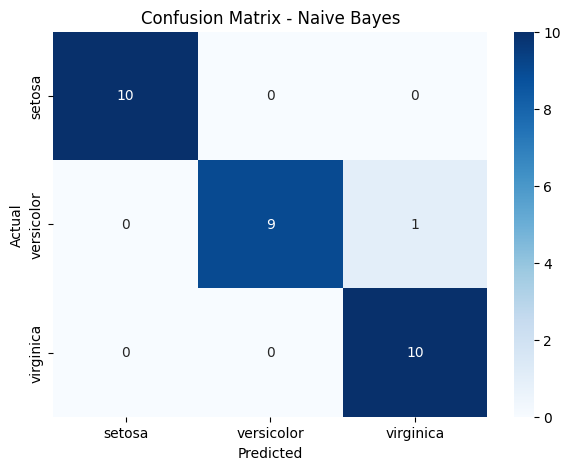

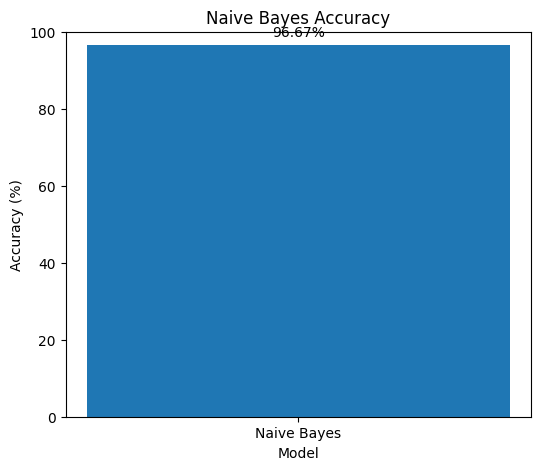

In [1]:
# ============================================
# NAIVE BAYES - IRIS DATASET
# ============================================

# 1. Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)
from sklearn.datasets import load_iris


# ============================================
# 2. Load Iris Dataset
# ============================================

iris = load_iris()

X = iris.data
y = iris.target

# Convert into DataFrame
df = pd.DataFrame(
    X,
    columns=iris.feature_names
)

df["target"] = y

print("First 5 rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)


# ============================================
# 3. Split Dataset
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# ============================================
# 4. Create Naive Bayes Model
# ============================================

model = GaussianNB()

model.fit(X_train, y_train)


# ============================================
# 5. Prediction
# ============================================

y_pred = model.predict(X_test)


# ============================================
# 6. Calculate Accuracy
# ============================================

accuracy = accuracy_score(y_test, y_pred)

print("\n================================")
print("Naive Bayes Accuracy")
print("================================")

print("Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")


# ============================================
# 7. Classification Report
# ============================================

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=iris.target_names
    )
)


# ============================================
# GRAPH 1
# Actual vs Predicted Values
# ============================================

plt.figure(figsize=(8, 5))

plt.plot(
    range(len(y_test)),
    y_test,
    marker='o',
    label="Actual"
)

plt.plot(
    range(len(y_pred)),
    y_pred,
    marker='x',
    label="Predicted"
)

plt.xlabel("Test Sample")
plt.ylabel("Class")
plt.title("Actual vs Predicted - Naive Bayes")
plt.legend()
plt.grid(True)

plt.show()


# ============================================
# GRAPH 2
# Confusion Matrix
# ============================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Naive Bayes")

plt.show()


# ============================================
# GRAPH 3
# Accuracy Graph
# ============================================

plt.figure(figsize=(6, 5))

plt.bar(
    ["Naive Bayes"],
    [accuracy * 100]
)

plt.ylabel("Accuracy (%)")
plt.xlabel("Model")
plt.title("Naive Bayes Accuracy")

plt.ylim(0, 100)

plt.text(
    0,
    accuracy * 100 + 2,
    f"{accuracy * 100:.2f}%",
    ha="center"
)

plt.show()